# Problème d'arrêt optimal jeu de cartes et convergence vers le pont brownien
**Référence :** Ekström, E. & Vaicenavicius, J. (2020). *Optimal stopping of a Brownian bridge with an unknown pinning point*. Stochastic Processes and their Applications, 130(2), 806–823.


## Imports


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


## Partie I: Modélisation et programmation dynamique

### Cadre du problème

On tire sans remise depuis un paquet de $2N$ cartes ($N$ rouges $= +1$, $N$ noires $= -1$).
Après $k = 2N-(r+b)$ tirages, le **gain total** est $G_k = b - r$.

**Fonction valeur** :
$$V(r, b) = \sup_{k \leq \tau \leq 2N} \, \mathbb{E}[G_\tau \mid R_k = r, B_k = b].$$

**Équation de Bellman** :
$$V(r, b) = \max\!\left(b - r,\; \frac{r}{r+b}\,V(r-1,b) + \frac{b}{r+b}\,V(r,b-1)\right),$$
avec $V(0, b) = b$ et $V(r, 0) = 0$.


### Backward induction


In [3]:
def compute_V(N):
    """  Retourne la table complete V[r,b] pour r,b dans {0,...,N}. """
    V = np.zeros((N+1, N+1))
    for b in range(1, N+1):
        V[0, b] = b      # bord r=0 : arreter immediatement
    # bord b=0 : V[r,0]=0 par initialisation
    # (continuer jusqu'epuisement, gain final = 0)
    for r in range(1, N+1):
        for b in range(1, N+1):
            p = r / (r + b)
            continuation = p * V[r-1, b] + (1-p) * V[r, b-1]
            V[r, b] = max(b - r, continuation)
    return V

# Pour N = 26
V26 = compute_V(26)
print(f'V(26,26) = {V26[26,26]:.4f} dollars')


V(26,26) = 2.6245 dollars


### Table des résultats pour différents $N$


In [4]:
N_list = [1, 2, 5, 10, 20, 26, 50, 100, 200, 500, 1000]

print(f"{'N':>6} | {'V(N,N)':>10} | {'V(N,N)/sqrt(N)':>16}")
print('-' * 40)
for n in N_list:
    V = compute_V(n)
    v = V[n, n]
    print(f'{n:>6} | {v:>10.6f} | {v/np.sqrt(n):>16.6f}')


     N |     V(N,N) |   V(N,N)/sqrt(N)
----------------------------------------
     1 |   0.500000 |         0.500000
     2 |   0.666667 |         0.471405
     5 |   1.119048 |         0.500453
    10 |   1.607228 |         0.508250
    20 |   2.295859 |         0.513370
    26 |   2.624476 |         0.514702
    50 |   3.658141 |         0.517339
   100 |   5.191092 |         0.519109
   200 |   7.356939 |         0.520214
   500 |  11.651523 |         0.521072
  1000 |  16.489496 |         0.521444


### Frontière d'arrêt optimal

**Définition.** La *région de continuation* est
$$\mathcal{C} = \{(r,b) \in [|0,N|]: V(r,b) > b-r\}, \qquad \mathcal{A} = \{(r,b) \in  [|0,N|] : V(r,b) = b-r\}.$$

Pour chaque $r$, le seuil de frontière est :
$$b^*(r) = \max\{b \in [|1,N|] : V(r,b) > b - r\}$$
(dernier $b$ pour lequel il est encore optimal de continuer le tirage).

**Représentation normalisée.** Pour comparer à la limite continue proposée dans (Ekström, 2020) on pose :
$$t = \frac{2N - r - b}{2N} \in [0,1], \qquad x = \frac{b-r}{\sqrt{2N}}.$$
La frontière dans l'espace $(t, x)$ converge vers $b(t) = \beta_{EW}\sqrt{1-t}$.
Où t représente la proportion de cartes déjà tirées parmi les $2N$ dans l'état $(r, b)$, et $x$ le gain normalisé.


### Calcul de la frontière


In [5]:
def frontiere_normalisee(N, V=None):
    """
    Frontiere d'arret optimal dans l'espace normalise.

    Pour chaque r, b_star(r) est le dernier point en region de continuation.
    On renvoie (t, x) = ((2N-r-b_star)/(2N), (b_star-r)/sqrt(2N)).
    """
    if V is None:
        V = compute_V(N)
    t_front, x_front = [], []
    for r in range(1, N+1):
        b_star = None
        for b in range(N, 0, -1):      # descendre de N vers 1
            if V[r, b] > b - r:   # continuation stricte
                b_star = b
                break
        if b_star is not None:
            t_front.append((2*N - r - b_star) / (2*N))
            x_front.append((b_star - r) / np.sqrt(2*N))
    order = np.argsort(t_front)
    return np.array(t_front)[order], np.array(x_front)[order]

t_fr, x_fr = frontiere_normalisee(26, V26)
print(f'Frontiere N=26 : {len(t_fr)} points')
print(f'  t dans [{t_fr.min():.3f}, {t_fr.max():.3f}]')
print(f'  Gain normalisé dans [{x_fr.min():.3f}, {x_fr.max():.3f}]')


Frontiere N=26 : 26 points
  t dans [0.000, 0.962]
  Gain normalisé dans [0.000, 0.693]


### Frontière théorique

La frontière continue est $b(t) = \beta_{EW}\,\sqrt{1-t}$ où $\beta_{EW}$ 
est l'unique racine positive de :

$f(\beta) = \sqrt{2\pi}\,(1 - \beta^2)\,e^{\beta^2/2}\,\Phi(\beta) - \beta = 0$
(Ekström, 2020).


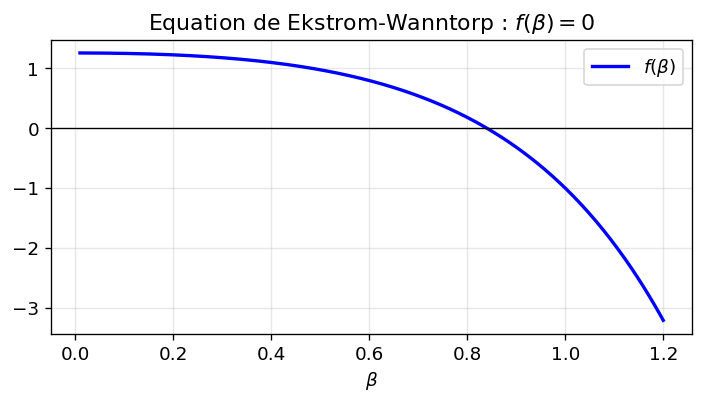

beta_EW = 0.83992368
Verification : f(beta_EW) = 1.15e-12


In [6]:
def func_aux(beta):
    """Equation d'Ekström"""
    return np.sqrt(2*np.pi) * (1 - beta**2) * np.exp(beta**2/2) * norm.cdf(beta) - beta

# Tracé pour voir l'unique racine
bv = np.linspace(0.01, 1.2, 400)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(bv, [func_aux(b) for b in bv], 'b-', lw=2, label=r'$f(\beta)$')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel(r'$\beta$')
ax.set_title(r'Equation de Ekstrom-Wanntorp : $f(\beta) = 0$')
ax.grid(True, alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

beta_EW = brentq(func_aux, 0.01, 1.0, xtol=1e-12) # Résolution numérique de l'équation d'Ekström
print(f'beta_EW = {beta_EW:.8f}')
print(f'Verification : f(beta_EW) = {func_aux(beta_EW):.2e}')


### Convergence de la frontière discrète vers la frontière continue


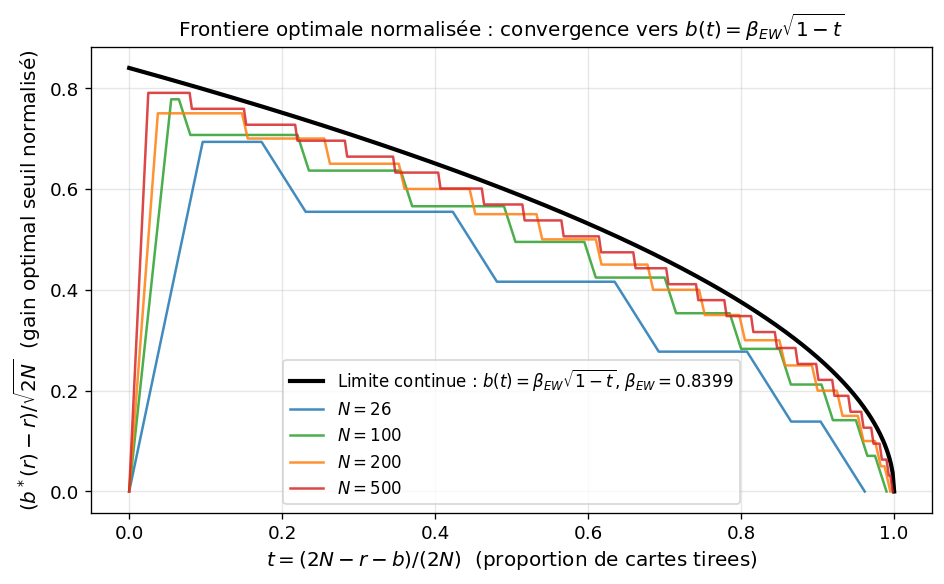

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

t_th = np.linspace(0, 1, 500)
ax.plot(t_th, beta_EW * np.sqrt(1 - t_th), 'k-', lw=2.5,
        label=f'Limite continue : $b(t) = \\beta_{{EW}}\\sqrt{{1-t}}$,'
              f' $\\beta_{{EW}} = {beta_EW:.4f}$')

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
for idx, Nv in enumerate([26, 100, 200, 500]):
    Vv = compute_V(Nv)
    tf, xf = frontiere_normalisee(Nv, Vv)
    ax.plot(tf, xf, color=colors[idx], lw=1.5, alpha=0.85, label=f'$N = {Nv}$')

ax.set_xlabel(r'$t = (2N-r-b)/(2N)$  (proportion de cartes tirees)', fontsize=12)
ax.set_ylabel(r'$(b^*(r)-r)/\sqrt{2N}$  (gain optimal seuil normalisé)', fontsize=12)
ax.set_title(r'Frontiere optimale normalisée : convergence vers $b(t) = \beta_{EW}\sqrt{1-t}$',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Partie II: Analyse asymptotique

### Convergence de $V(N,N)/\sqrt{N}$


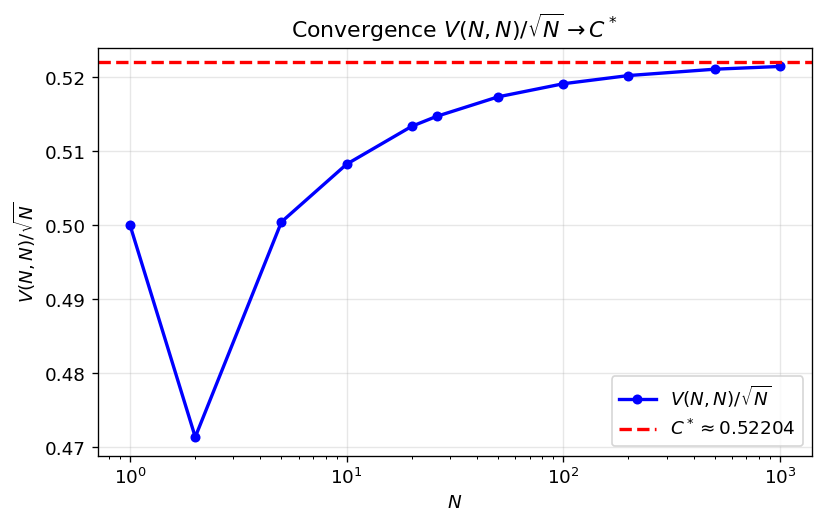

In [8]:
ratios = [compute_V(n)[n, n] / np.sqrt(n) for n in N_list]
C_star = 0.52204

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(N_list, ratios, 'bo-', ms=5, lw=2, label=r'$V(N,N)/\sqrt{N}$')
ax.axhline(C_star, color='r', ls='--', lw=2, label=f'$C^* \\approx {C_star}$')
ax.set_xlabel('$N$')
ax.set_ylabel(r'$V(N,N)/\sqrt{N}$')
ax.set_title(r'Convergence $V(N,N)/\sqrt{N} \to C^*$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Trajectoires discrètes vs pont brownien + frontière


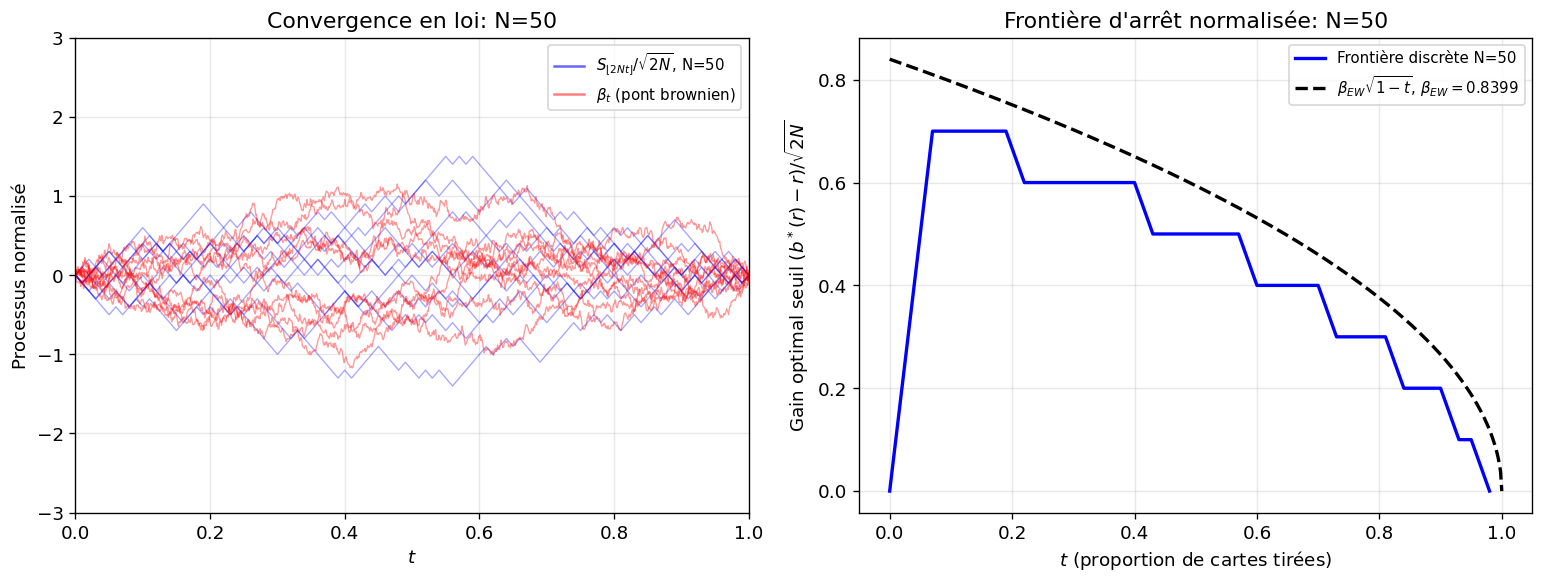

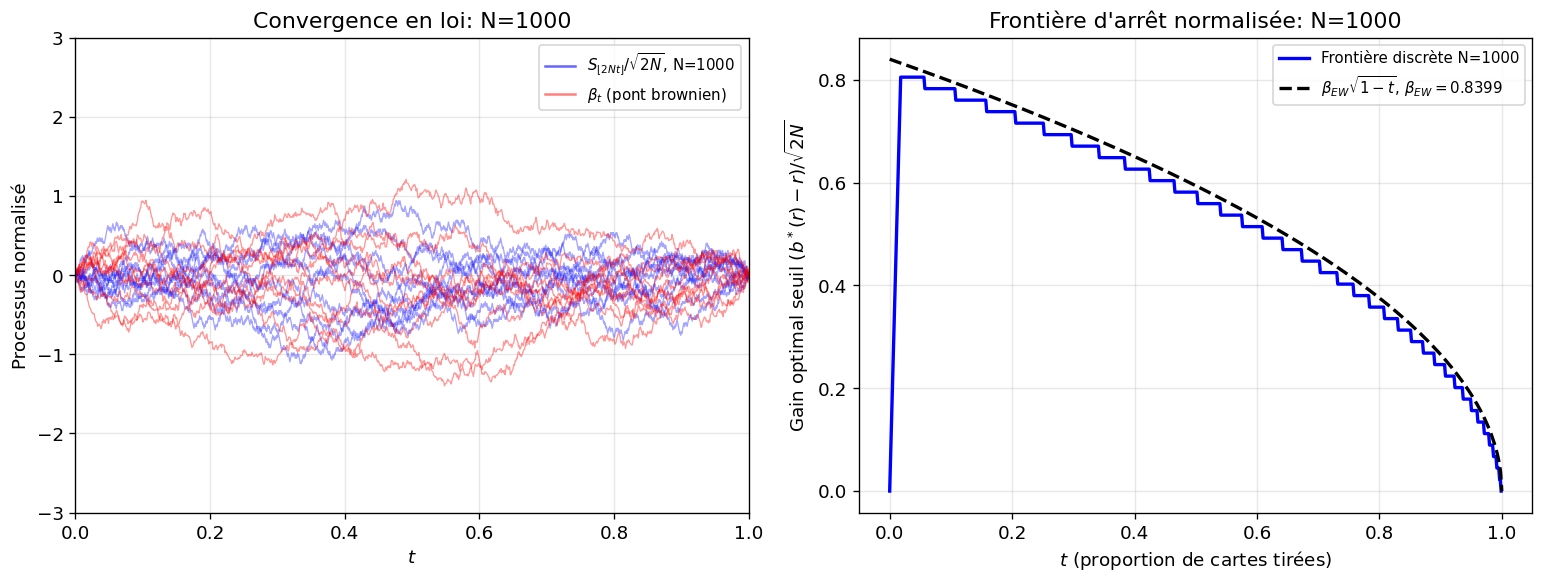

In [9]:
for N_demo in [50, 1000]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Panneau gauche : trajectoires normalisées par sqrt(2N) -> limite = pont brownien
    ax = axes[0]
    t_disc = np.linspace(0, 1, 2*N_demo + 1)
    for _ in range(10):
        deck = np.array([1]*N_demo + [-1]*N_demo, dtype=float)
        np.random.shuffle(deck)
        path = np.concatenate([[0], np.cumsum(deck)]) / np.sqrt(2*N_demo)
        ax.plot(t_disc, path, 'b-', alpha=0.35, lw=0.8)
    
    steps = 1000
    dt = 1/steps
    t_bb = np.linspace(0, 1, steps+1)

    for _ in range(10):
        dW = np.sqrt(dt)*np.random.randn(steps)
        W  = np.concatenate([[0], np.cumsum(dW)])
        B  = W - t_bb*W[-1]
        ax.plot(t_bb, B, 'r-', alpha=0.4, lw=0.8)
    
    ax.plot([], [], 'b-', alpha=0.6,
            label=f'$S_{{\\lfloor 2Nt\\rfloor}}/\\sqrt{{2N}}$, N={N_demo}')
    ax.plot([], [], 'r-', alpha=0.5, label=r'$\beta_t$ (pont brownien)')
    ax.set_xlabel('$t$')
    ax.set_ylabel('Processus normalisé')
    ax.set_title(f'Convergence en loi: N={N_demo}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([-3, 3])

    # Panneau droit : frontière discrete vs frontière théorique
    ax2 = axes[1]
    Vv = compute_V(N_demo)
    tf, xf = frontiere_normalisee(N_demo, Vv)
    ax2.plot(tf, xf, 'b-', lw=2, label=f'Frontière discrète N={N_demo}')
    t_th2 = np.linspace(0, 1, 500)
    ax2.plot(t_th2, beta_EW*np.sqrt(1-t_th2), 'k--', lw=2,
             label=f'$\\beta_{{EW}}\\sqrt{{1-t}}$, $\\beta_{{EW}}={beta_EW:.4f}$')
    ax2.set_xlabel(r'$t$ (proportion de cartes tirées)')
    ax2.set_ylabel(r'Gain optimal seuil $(b^*(r)-r)/\sqrt{2N}$')
    ax2.set_title(f"Frontière d'arrêt normalisée: N={N_demo}")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## Conclusion

> $V(26,26)$  $\approx 2.624$ dollars

> $C^* = \lim_N V(N,N)/\sqrt{N}$  $\approx 0.5220$

> $v^* = C^*/\sqrt{2}$  $\approx 0.369$ 

> Borne : $C^* \le \sqrt{\pi}/2$  $\approx 0.886$ 

**Règle optimale :** s'arrêter en $(r,b)$ dès que
$b - r \ge \frac{r}{r+b}V(r-1,b) + \frac{b}{r+b}V(r,b-1).$

**Frontière continue :** $b(t) = \beta_{EW}\sqrt{1-t}$,
$\beta_{EW} \approx 0.8399$ solution de l'équation de Ekström.
